# Classical Portfolio Demo

This notebook demonstrates the full Phase 1 classical portfolio pipeline: market data loading, return estimation, covariance estimation, Markowitz optimization, portfolio metrics, and efficient frontier generation.

## 1. Setup

Import the project functions used throughout the pipeline. The notebook keeps logic in the backend modules and uses this file only to orchestrate the workflow and display results.

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from backend.analysis.metrics import (
    compute_portfolio_return,
    compute_portfolio_volatility,
    compute_sharpe_ratio,
)
from backend.classical.efficient_frontier import generate_efficient_frontier
from backend.classical.markowitz import optimize_portfolio
from backend.data.covariance import compute_covariance_matrix
from backend.data.market_data import fetch_price_data
from backend.data.returns import compute_annualized_returns, compute_daily_returns

pd.options.display.float_format = "{:.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Define Tickers

The demo uses a small cross-asset ETF universe: broad U.S. equities, growth-oriented equities, dividend growth equities, long-term Treasuries, and gold.

In [11]:
tickers = ["SPY", "QQQ", "VIG", "TLT", "GLD"]
tickers

['SPY', 'QQQ', 'VIG', 'TLT', 'GLD']

## 3. Fetch Historical Price Data

`fetch_price_data` retrieves adjusted close prices when available and returns a clean date-indexed DataFrame.

In [12]:
prices = fetch_price_data(tickers, period="5y")
prices.head()

,SPY,QQQ,VIG,TLT,GLD
Date,,,,,
2021-05-03,390.5916,326.2489,140.5179,117.7490,167.8100
2021-05-04,388.1819,320.3779,140.7184,118.5481,166.5800
2021-05-05,388.3034,319.3006,140.8278,118.7436,167.2700
2021-05-06,391.4042,321.7073,142.0310,118.9391,170.0600
2021-05-07,394.2528,324.3177,142.7967,118.3525,171.5900


## 4. Compute Returns and Covariance

Daily returns are computed from prices. Expected returns and the covariance matrix are annualized using the standard 252-trading-day convention.

In [13]:
daily_returns = compute_daily_returns(prices)
expected_returns = compute_annualized_returns(daily_returns)
covariance_matrix = compute_covariance_matrix(daily_returns)

expected_returns.to_frame("annualized_expected_return")

,annualized_expected_return
SPY,0.1376
QQQ,0.1709
VIG,0.1077
TLT,-0.0514
GLD,0.2019


In [14]:
covariance_matrix

,SPY,QQQ,VIG,TLT,GLD
SPY,0.0292,0.0365,0.0229,0.0019,0.0039
QQQ,0.0365,0.0503,0.0264,0.0025,0.0047
VIG,0.0229,0.0264,0.0204,0.0021,0.0034
TLT,0.0019,0.0025,0.0021,0.0251,0.0060
GLD,0.0039,0.0047,0.0034,0.0060,0.0320


## 5. Run Markowitz Optimization

The Markowitz optimizer chooses long-only portfolio weights that maximize expected return minus a covariance-based risk penalty.

In [15]:
weights = optimize_portfolio(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    risk_aversion=1.0,
)

weights.to_frame("optimized_weight")

,optimized_weight
SPY,0.0000
QQQ,0.1618
VIG,0.0000
TLT,0.0000
GLD,0.8382


## 6. Compute Portfolio Metrics

The optimized weights are evaluated using expected portfolio return, portfolio volatility, and Sharpe ratio.

In [16]:
portfolio_return = compute_portfolio_return(weights, expected_returns)
portfolio_volatility = compute_portfolio_volatility(weights, covariance_matrix)
sharpe_ratio = compute_sharpe_ratio(portfolio_return, portfolio_volatility)

portfolio_metrics = pd.Series(
    {
        "expected_return": portfolio_return,
        "volatility": portfolio_volatility,
        "sharpe_ratio": sharpe_ratio,
    },
    name="optimized_portfolio",
)

portfolio_metrics.to_frame()

,optimized_portfolio
expected_return,0.1969
volatility,0.1583
sharpe_ratio,1.2440


## 7. Generate Efficient Frontier

The efficient frontier is generated by solving minimum-variance portfolios across a range of target returns.

In [17]:
frontier = generate_efficient_frontier(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    num_points=50,
)

frontier.head()

,target_return,expected_return,volatility,sharpe_ratio,weights
0,-0.0514,0.0760,0.1029,0.7385,SPY 0.0000 QQQ 0.0000 VIG 0.4478 TLT 0...
1,-0.0462,0.0760,0.1029,0.7385,SPY 0.0000 QQQ 0.0000 VIG 0.4478 TLT 0...
2,-0.0411,0.0760,0.1029,0.7385,SPY 0.0000 QQQ 0.0000 VIG 0.4478 TLT 0...
3,-0.0359,0.0760,0.1029,0.7385,SPY 0.0000 QQQ 0.0000 VIG 0.4478 TLT 0...
4,-0.0307,0.0760,0.1029,0.7385,SPY 0.0000 QQQ 0.0000 VIG 0.4478 TLT 0...


## 8. Plot Efficient Frontier

The plot shows annualized volatility on the x-axis and annualized expected return on the y-axis. The optimized Markowitz portfolio is highlighted for comparison.

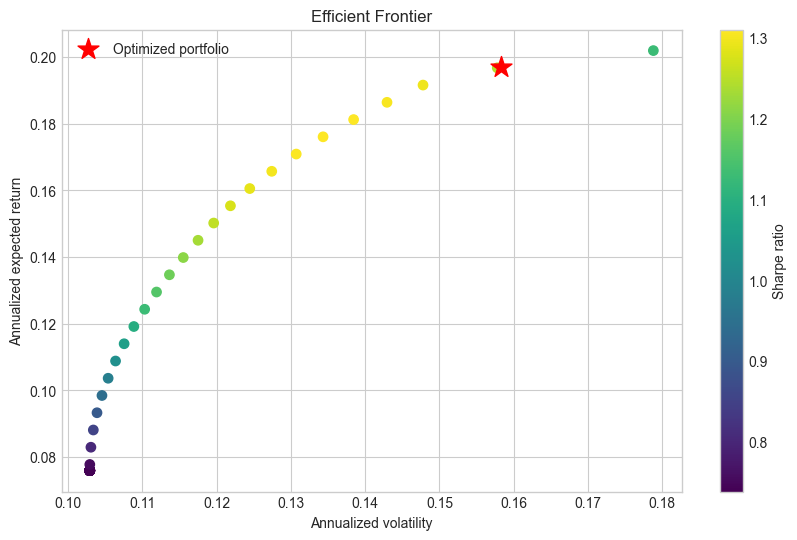

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    frontier["volatility"],
    frontier["expected_return"],
    c=frontier["sharpe_ratio"],
    cmap="viridis",
    s=45,
)
ax.scatter(
    portfolio_volatility,
    portfolio_return,
    color="red",
    marker="*",
    s=250,
    label="Optimized portfolio",
)

ax.set_title("Efficient Frontier")
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized expected return")
ax.legend()
fig.colorbar(scatter, ax=ax, label="Sharpe ratio")

plt.show()